<a href="https://colab.research.google.com/github/ShivanshuK12399/Customer-Churn-Dataset/blob/main/Customer_Churn_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Set the path to the file you'd like to load
file_path=kagglehub.dataset_download("blastchar/telco-customer-churn")
print("path:",file_path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
path: /kaggle/input/telco-customer-churn


Preprocessing / Cleaning

In [2]:
import pandas as pd
import numpy as np

data_file=pd.read_csv(file_path+"/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df=data_file

print(f"Shape {df.shape}\n")
# df.info()
# print(f"Total null values in DataFrame {df.isnull().sum().sum()}\n")
df.head()

#deleting useless data
df.drop(columns=['customerID'],inplace=True)

#types of values in these columns
col=["MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","Contract","PaymentMethod"]
# print(f"Unique values in columns:")
# for c in col:
  # print(f"{c} {df[c].unique()}")
# print()

#data types of numerical columns
col=df[["tenure","MonthlyCharges","TotalCharges"]]
# print(f"Data types of columns:")
# for c in col:
  # print(c,": ",df[c].dtype)
# print()

# changing datatypes
# print(df['TotalCharges'].apply(type).value_counts())
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors="coerce") # row 488 has Nan value
df.dropna(inplace=True) # Drop rows with any NaN values and update df
# print(f"Shape after dropping NaN values: {df.shape}")

# changing values
df['SeniorCitizen']=df['SeniorCitizen'].apply(lambda x: 'Yes' if(x==1) else 'No')

df.head(5)

Shape (7043, 21)



,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Correlation

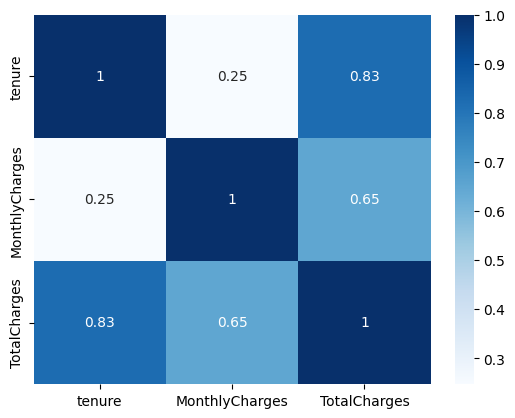

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='Blues')
plt.show()

Percentages

In [4]:
#Chrun rate
churn_rate=df["Churn"].value_counts(normalize=True)
print(f"{churn_rate.apply(lambda x: f"{round(x*100,2)}%")}")

churn_tenure=df.groupby('Churn')['tenure'].mean()
print(f"\nTenure mean of customers who churned:\n{round(churn_tenure,2).to_string(header=False)}")

churn_mcharges=df.groupby('Churn')['MonthlyCharges'].mean()
print(f"\nMonthly charges:\n{round(churn_mcharges,2).to_string(header=False)}")


#Some Columns info
print(f"\nColumns with two Values: {[col for col in df.columns if df[col].nunique() == 2]}")

Churn
No     73.42%
Yes    26.58%
Name: proportion, dtype: object

Tenure mean of customers who churned:
No     37.65
Yes    17.98

Monthly charges:
No     61.31
Yes    74.44

Columns with two Values: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']


Splitting Data

In [5]:
from sklearn.model_selection import train_test_split

# Spliting data
x=df.drop(columns='Churn')
y=df['Churn']

x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=6)
# print(x_train.dtypes)

Pipelining

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

num_cols = x.select_dtypes(include=['int64', 'float64']).columns
cat_cols = x.select_dtypes(include=['object']).columns

# Encoding & Scaling
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# print(f"Total features: {np.concatenate([num_cols, cat_cols]).size}")

# Training
pipeline=Pipeline(
    [("preprocessor", preprocessor),
    ("model",LogisticRegression(class_weight='balanced', max_iter=1000))])

print(pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])


Encoding

In [7]:
from sklearn.preprocessing import LabelEncoder

lb=LabelEncoder()

# Label Encoding for the target variable y_train and y_test
# Pipelining handle features not targets, so we will encode y train_test manually
y_train = lb.fit_transform(y_train)
y_test = lb.transform(y_test)

Training

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

scores = cross_val_score(pipeline, x_train, y_train, cv=StratifiedKFold(n_splits=5), scoring='roc_auc')
print(scores.dtype)
print(np.round(scores.mean(),2))

pipeline.fit(x_train,y_train)
y_pred=pipeline.predict(x_test)

y_pred_prob = pipeline.predict_proba(x_test)[:,1]
print(roc_auc_score(y_test, y_pred_prob))

float64
0.84
0.8638171440485807


Plotting

Correct predictions: 1074
False predictions: 333



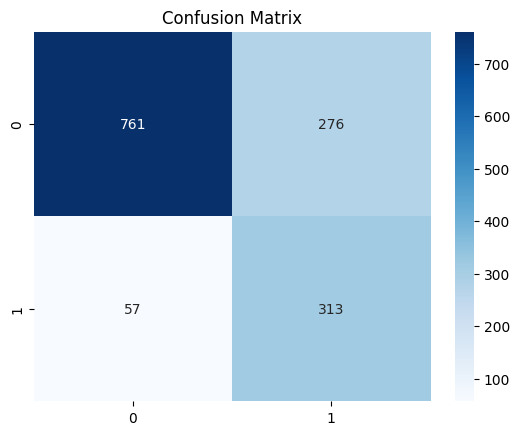

              precision    recall  f1-score   support

           0       0.93      0.73      0.82      1037
           1       0.53      0.85      0.65       370

    accuracy                           0.76      1407
   macro avg       0.73      0.79      0.74      1407
weighted avg       0.83      0.76      0.78      1407



In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

con_matrix=confusion_matrix(y_test,y_pred)
print(f"Correct predictions: {con_matrix[0,0]+con_matrix[1,1]}")
print(f"False predictions: {con_matrix[0,1]+con_matrix[1,0]}\n")

sns.heatmap(con_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test,y_pred))